In [22]:
import math

import torch
from torch import nn
from d2l import torch as d2l

In [23]:
# Sequence mask

def sequence_mask(
    X: torch.Tensor,
    valid_lens: torch.Tensor,
    value: float = 0.0,
) -> torch.Tensor:
    # X: [N, K]
    
    num_keys = X.shape[1]
    
    # [1, K]: [0, 1, ... , K-1]
    positions = torch.arange(
        num_keys,
        device=X.device,
    ).reshape(1, -1)
    
    # [1, K] < [N, 1] -> [N, K]
    mask = (
        positions
        < valid_lens.to(
            device=X.device
        ).reshape(-1, 1)
    )
    
    masked_X = X.clone()
    masked_X[~mask] = value

    return masked_X


# Masked Softmax

def masked_softmax(
    X: torch.Tensor,
    valid_lens: torch.Tensor | None,
) -> torch.Tensor:
    # X: [B, Q, K]
    
    if valid_lens is None:
        return nn.functional.softmax(
            X,
            dim=-1,
        )
        
    original_shape = X.shape

    if valid_lens.ndim == 1:
        # [B] -> [B * Q]
        flattened_valid_lens =  (
            torch.repeat_interleave(
                valid_lens,
                repeats=original_shape[1] # Q
            )
        )
        
    else: 
        # [B, Q] -> [B * Q]
        flattened_valid_lens = (
            valid_lens.reshape(-1)
        )
        
        
    # [B, Q, K] -> [B * Q, K]
    flattened_X = X.reshape(
        -1,
        original_shape[-1],
    )

    masked_X = sequence_mask(
        X=flattened_X,
        valid_lens=flattened_valid_lens,
        value=-1e6,
    )

    return nn.functional.softmax(
        masked_X.reshape(original_shape),
        dim=-1,
    )

In [24]:
# Scaled dot product Attention data flow

batch_size = 2
num_queries = 1
num_keys = 10
query_key_dim = 2
value_dim = 4


# Queries: [B, Q, D] = [2, 1, 2]
queries = torch.normal(
    mean=0.0,
    std=1.0,
    size=(
        batch_size,
        num_queries,
        query_key_dim,
    ),
)

# Keys: [B, K, D] = [2, 10, 2]
keys = torch.normal(
    mean=0.0,
    std=1.0,
    size=(
        batch_size,
        num_keys,
        query_key_dim,
    ),
)


# Values: [B, K, V]= [2, 10, 4]
values = torch.normal(
    mean=0.0,
    std=1.0,
    size=(
        batch_size,
        num_keys,
        value_dim,
    ),
)



valid_lens = torch.tensor([
    2,
    6,
])

# [B, K, D] -> [B, D, K] = [2, 2, 10]
transposed_keys = keys.transpose(
    1,
    2,
)

# Q   :[B, Q, D] = [2, 1, 2]
# K.T :[B, D, K] = [2, 2, 10]
# Q @ K.T -> [B, Q, K] = [2, 1, 10]
scores = torch.bmm(
    queries,
    transposed_keys,
)

# scores ÷ √D 
# scaled_score: [B, Q, K] = [2, 1, 10]
scaled_scores = (
    scores
    / math.sqrt(query_key_dim)
)

# Attention weights: [B, Q, K] = [2, 1, 10]
attention_weights = masked_softmax(
    X=scaled_scores,
    valid_lens=valid_lens,
)


# [B, Q, K] @ [B, K, V] -> [B, Q, V]
# = [2, 1, 10] @ [2, 10, 4] = [2, 1, 4]
attention_output = torch.bmm(
    attention_weights,
    values,
)

print(
    "Queries shape:",
    tuple(queries.shape),
)
print(
    "Keys shape:",
    tuple(keys.shape),
)
print(
    "Transposed Keys shape:",
    tuple(transposed_keys.shape),
)
print(
    "Scores shape:",
    tuple(scores.shape),
)
print(
    "Attention Weights shape:",
    tuple(attention_weights.shape),
)
print(
    "Attention Output shape:",
    tuple(attention_output.shape),
)

Queries shape: (2, 1, 2)
Keys shape: (2, 10, 2)
Transposed Keys shape: (2, 2, 10)
Scores shape: (2, 1, 10)
Attention Weights shape: (2, 1, 10)
Attention Output shape: (2, 1, 4)


In [25]:
# Scaled Dot product attention

# Queries: [B, Q, D]
# Keys   : [B, K, D]
# Values : [B, K, V]

#   Keys
# [B, K, D]
#     ↓ transpose
# [B, D, K]

# Query & Key의 dot product
# [B, Q, D] @ [B, D, K]
#                 ↓
#      Scores [B, Q, K]

# Scale & Masking
# Scores
#   ↓ ÷ √D
# Scaled Scores
#   ↓ Masked Softmax
# Attention Weights [B, Q, K]

# Value 결합
# Attention weights: [B, Q, K]
# Values           : [B, K, V]
#                        ↓
# Output           : [B, Q, V]

class DotProductAttention(nn.Module):
    
    def __init__(
        self,
        dropout: float,
    ) -> None:
        super().__init__()
        
        self.dropout = nn.Dropout(
            p=dropout
        )
        
        self.attention_weights: (
            torch.Tensor | None 
        ) = None
        
        
    def forward(
        self,
        queries: torch.Tensor, # [B, Q, D]
        keys: torch.Tensor,    # [B, K, D]
        values: torch.Tensor,  # [B, K, V]
        valid_lens: torch.Tensor | None = None,
    ) -> torch.Tensor:
        
        query_key_dim = queries.shape[-1] # D
        
        
        # K.T:
        # [B, K, D] -> [B, D, K]
        #
        # scores: Q @ K.T
        # [B, Q, D] @ [B, D, K] -> [B, Q, K]
        scores = (
            torch.bmm(
                queries,
                keys.transpose(1, 2),
            )
            / math.sqrt(query_key_dim)
        )
        
        # [B, Q, K]
        self.attention_weights= (
            masked_softmax(
                X=scores,
                valid_lens=valid_lens,
            )
        )
        
        # [B, Q, K] @ [B, K, V]
        # -> [B, Q, V]
        return torch.bmm(
            self.dropout(
                self.attention_weights
            ),
            values,
        )

In [28]:
# DotProductAttention Test

attention = DotProductAttention(
    dropout=0.5
)

attention.eval()

output = attention(
    queries=queries,
    keys=keys,
    values=values,
    valid_lens=valid_lens,
)


print(
    "Output shape:",
    tuple(output.shape),
)

print(
    "\nOutput:"
)
print(
    output
)

d2l.check_shape(
    output,
    (
        2,
        1,
        4,
    ),
)

Output shape: (2, 1, 4)

Output:
tensor([[[-0.0041, -0.1089,  0.2714,  0.5680]],

        [[ 0.1323, -0.3063, -0.6937,  0.2544]]])


Attention Weight shape: (2, 1, 10)

Batch 0 Weights:
tensor([[0.3477, 0.6523, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000]])

Batch 1 Weights:
tensor([[0.1530, 0.1765, 0.1812, 0.1570, 0.1885, 0.1438, 0.0000, 0.0000, 0.0000,
         0.0000]])

Weight Sums:
tensor([[1.],
        [1.]])


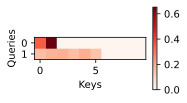

In [27]:
# Attention Weight Validation and Heatmap

if attention.attention_weights is None:
    raise RuntimeError(
        "Attention Weights were not computed."
    )

weights = attention.attention_weights

print(
    "Attention Weight shape:",
    tuple(weights.shape),
)

print(
    "\nBatch 0 Weights:"
)
print(
    weights[0]
)

print(
    "\nBatch 1 Weights:"
)
print(
    weights[1]
)

print(
    "\nWeight Sums:"
)
print(
    weights.sum(
        dim=-1
    )
)

# Batch 0은 index 2 이후가 모두 0
assert torch.count_nonzero(
    weights[0, :, 2:]
).item() == 0

# Batch 1은 index 6 이후가 모두 0
assert torch.count_nonzero(
    weights[1, :, 6:]
).item() == 0

torch.testing.assert_close(
    weights.sum(dim=-1),
    torch.ones(2, 1),
)

# [B=2, Q=1, K=10]
# -> [Display Row=1, Display Column=1, Query=2, Key=10]
d2l.show_heatmaps(
    weights.reshape(
        1,
        1,
        2,
        10,
    ),
    xlabel="Keys",
    ylabel="Queries",
)